In [4]:
SPLIT_DIR = "split_70_15_15_augmented"
SPLIT_SET = "train"
IMAGE_NAME = "pill_color_011.png"
DELETE_CONFIRM = False

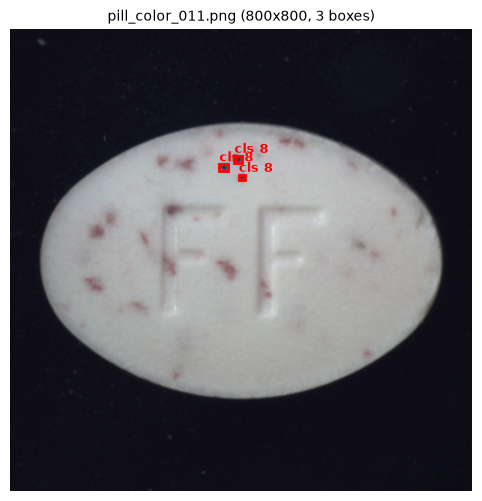

Image: ..\data\processed\split_70_15_15_augmented\images\train\pill_color_011.png
Label: ..\data\processed\split_70_15_15_augmented\labels\train\pill_color_011.txt (exists: True)


In [5]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

data_dir = Path("../data") if Path("../data").exists() else Path("data")
img_path = data_dir / "processed" / SPLIT_DIR / "images" / SPLIT_SET / IMAGE_NAME
lbl_path = data_dir / "processed" / SPLIT_DIR / "labels" / SPLIT_SET / f"{img_path.stem}.txt"

if not img_path.exists():
    print(f"File ảnh không tồn tại: {img_path}")
else:
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)

    box_count = 0
    if lbl_path.exists():
        with open(lbl_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id, cx, cy, bw, bh = parts[0], *map(float, parts[1:5])
                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw * w, bh * h, linewidth=2, edgecolor="red", facecolor="none"
                    )
                    ax.add_patch(rect)
                    ax.text(x1, max(0, y1 - 5), f"cls {cls_id}", color="red", fontsize=9, weight="bold")
                    box_count += 1

    ax.set_title(f"{IMAGE_NAME} ({w}x{h}, {box_count} boxes)", fontsize=10)
    ax.axis("off")
    plt.show()

    print(f"Image: {img_path}")
    print(f"Label: {lbl_path} (exists: {lbl_path.exists()})")

In [ ]:
if not DELETE_CONFIRM:
    print("Chế độ xem an toàn: Chưa xóa file. Đổi DELETE_CONFIRM = True ở Cell 1 nếu muốn xóa.")
else:
    deleted_files = []
    if img_path.exists():
        img_path.unlink()
        deleted_files.append(str(img_path))
    if lbl_path.exists():
        lbl_path.unlink()
        deleted_files.append(str(lbl_path))

    if deleted_files:
        print("Đã xóa thành công:")
        for p in deleted_files:
            print(f" - {p}")
    else:
        print("Không có file nào để xóa.")